In [1]:
import scanpy as sc

In [2]:
scdata = sc.read_h5ad(r'C:\Users\zgibbs\cellpose\400CRE_mouse_brain_20241211\scdata_12_11NoT7_BRBB500gn_withCRE_info.h5ad')
scdata

AnnData object with n_obs × n_vars = 251992 × 500
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'class', 'subclass'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CRE_info', 'cmap', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'CRE', 'X_raw', 'X_spatial', 'X_umap'
    obsp: 'connectivities', 'distances'

In [5]:
import numpy as np

cts_seq =  {int(ln.split('CRE')[-1]):int(ln.split('CRE')[0]) for ln in open(r'C:\Users\zgibbs\cellpose\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_4_sample_4_counts','r')}
cts_seq = np.array([cts_seq.get(i+1,0)for i in np.arange(400)])

pos_cells = np.where(np.array(list(scdata.uns['CRE_info']['labeling_type']))=='Positive control')[0]
ipositive = pos_cells[cts_seq[pos_cells]>500]

scdata.uns['CRE_info'].iloc[ipositive]

,enh,label,labeling_type,subclass_num,best_subclass,sequence
358,chr16:88203161−88203758,L5_NP_CTX_Glut,Positive control,,,CTTCATGTATGCAAGCCTTCTCTTATGTAACCTTTTGGCTTTCTGT...
362,chr14:31916858−31917442,Sst_Gaba,Positive control,,,TAGGTTTCTGCCCCTCCTCACTACCCTGCCAAGGACCTTGTCTGAA...
363,chr4:114636191−114636562,ODC_NN,Positive control,,,CCAGTATTTGAGTACTTTTGTTATTCTCTTTAAAAAGTCAGTATTA...
367,chr2:29394576−29395269,CLA-EPd-CTX_Car3_Glut,Positive control,,,GCCCAGTCTCCTGCCCCACTCCTGCCTCTGCCTATAAGAGTTTGGC...


In [6]:
pos_cells

array([356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367])

In [7]:
cts_seq[pos_cells]

array([  427,   145,  1786,   293,    59,    27, 45033,   979,    37,
          25,    11, 11641])

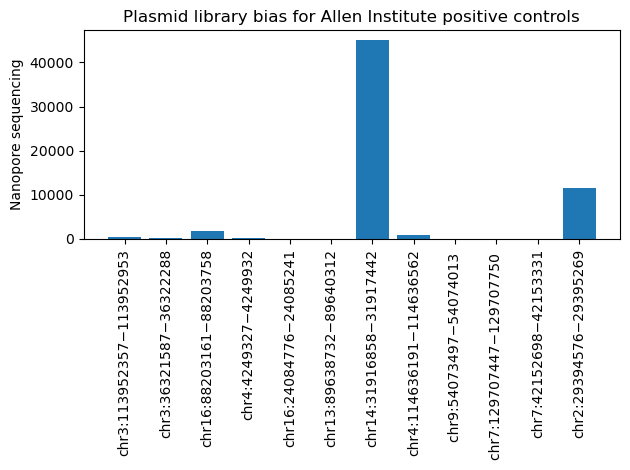

In [44]:
import matplotlib.pyplot as plt
plt.bar(scdata.uns['CRE_info']['enh'][pos_cells],cts_seq[pos_cells])
plt.xticks(rotation=90)
plt.ylabel('Nanopore sequencing')
plt.title('Plasmid library bias for Allen Institute positive controls')

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\241205_SFv8_mouse_brain\nanopore_positive_controls.png', dpi=300)
plt.show()

In [15]:
M = np.array(scdata.obsm['CRE']) 

In [21]:
np.sum(M[pos_cells], axis=1)

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 11.,  0.])

In [234]:
scdata.uns['CRE_info'][-40:]

,enh,label,labeling_type,subclass_num,best_subclass,sequence
360,chr16:24084776−24085241,L5_ET_CTX_Glut,Positive control,,,CTGTTATTCTTAAGAGCACACTGATATTACTCATTGTGTGAGGCAC...
361,chr13:89638732−89640312,LAMP5_Gaba,Positive control,,,AATTCAAATGTAGTATTGAAATGTATTTTCAGTGGCGAAAAGTGAG...
362,chr14:31916858−31917442,Sst_Gaba,Positive control,,,TAGGTTTCTGCCCCTCCTCACTACCCTGCCAAGGACCTTGTCTGAA...
363,chr4:114636191−114636562,ODC_NN,Positive control,,,CCAGTATTTGAGTACTTTTGTTATTCTCTTTAAAAAGTCAGTATTA...
364,chr9:54073497−54074013,LAMP5_Gaba,Positive control,,,CAAATTTCCCttttaattttattataattatatGACAAATAATGCT...
365,chr7:129707447−129707750,Pvalb_Gaba,Positive control,,,GAAGATTAAGCCCTTTCTTGCTCTATGTATTTGAGCCTAGAAAAAG...
366,chr7:42152698−42153331,pan Astro,Positive control,,,CTCATTCACCTCTCTCCAACCAGCTAGCCGCTCAGCTCAATTCACC...
367,chr2:29394576−29395269,CLA-EPd-CTX_Car3_Glut,Positive control,,,GCCCAGTCTCCTGCCCCACTCCTGCCTCTGCCTATAAGAGTTTGGC...
368,chr13:80315816-80316315,SUB-ProS_Glut,subclass,23.0,SUB-ProS_Glut,attaagataaacatttgagaaggtacatatgcttaatctgatataa...
369,chr3:8122419-8122918,SUB-ProS_Glut,subclass,23.0,SUB-ProS_Glut,TGCAATTCATTTAACTGTCTGTTCAGCCACCTACACATTTTGTCAT...


# plt.loglog(np.sum(M,axis=0)[pos_cells]+1,cts_seq[pos_cells]+1,'o')
plt.ylabel('Nanopore sequencing')
plt.xlabel('STARR-FISH total spots')
plt.title('Positive controls from Allen Institute data')
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\241205_SFv8_mouse_brain\positive_controls_seq_vs_imaging.png', dpi=300)

In [56]:
np.corrcoef(np.log(np.sum(M,axis=0)[:400]+1),np.log(cts_seq+1))

array([[1.        , 0.78060508],
       [0.78060508, 1.        ]])

In [194]:
sublibrary = np.array([i // 40 for i in range(400)])

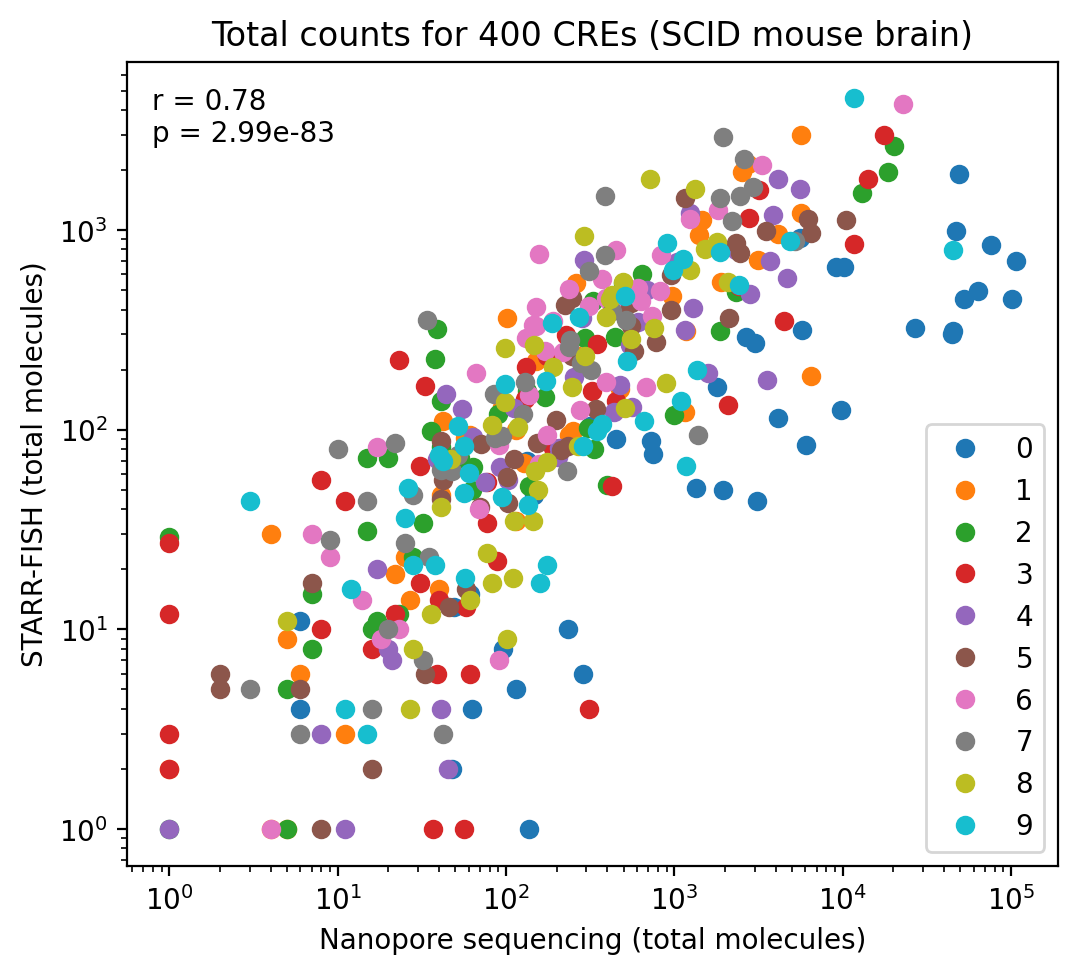

In [203]:
from scipy import stats
from matplotlib.offsetbox import AnchoredText
plt.style.use('default')


y = np.sum(M,axis=0)[:400]+1
x = cts_seq+1
fig, ax = plt.subplots(figsize=(5.5, 5))

for subl in np.unique(sublibrary):
    ax.loglog(x[sublibrary == subl], y[sublibrary ==subl],'o', label=subl)
    ax.set_xlabel('Nanopore sequencing (total molecules)')
    ax.set_ylabel('STARR-FISH (total molecules)')
    ax.set_title('Total counts for 400 CREs (SCID mouse brain)')

ax.legend()
stats = stats.pearsonr(np.log(x), np.log(y))

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)
plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\241205_SFv8_mouse_brain\totalcounts_seq_vs_imaging.pdf')
plt.show()

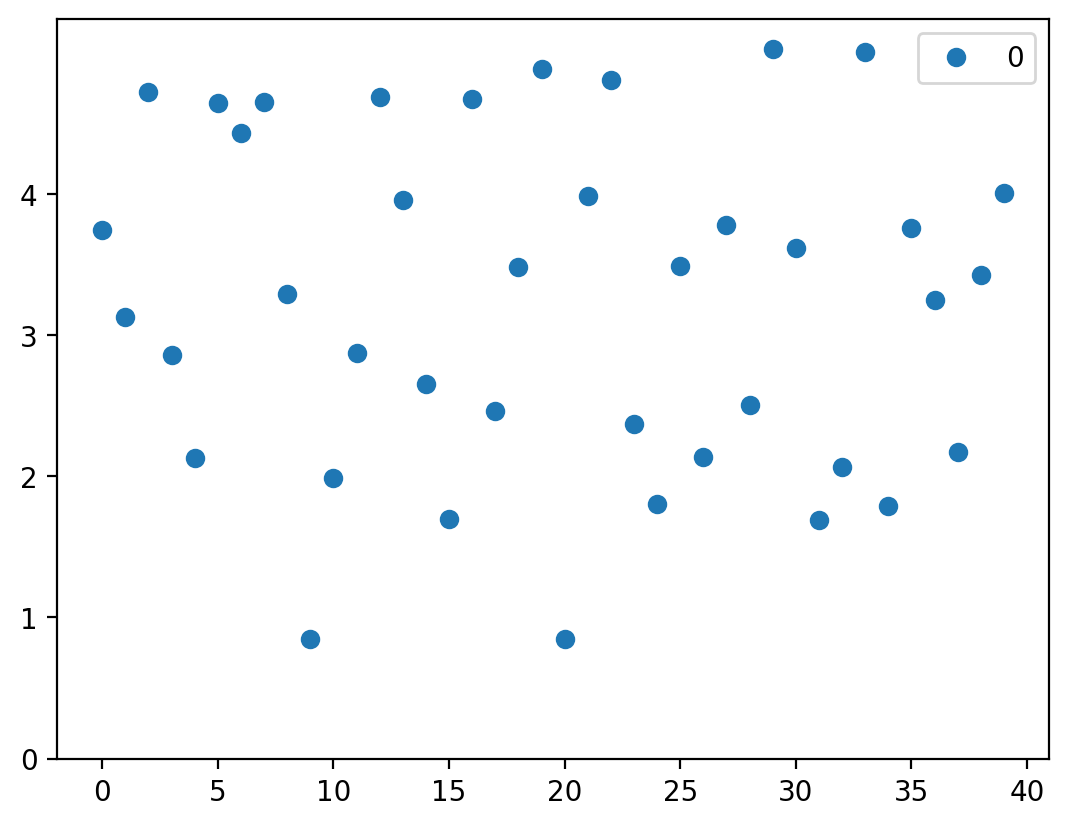

In [227]:
for subl in np.unique(sublibrary)[:1]:
    plt.plot(np.log10(x[sublibrary == subl]+1),'o', label=subl)
plt.legend()
_ =plt.yticks(np.arange(5))

In [222]:
np.sum(x[sublibrary == 0])/np.sum(x)

np.float64(0.6268601378721541)

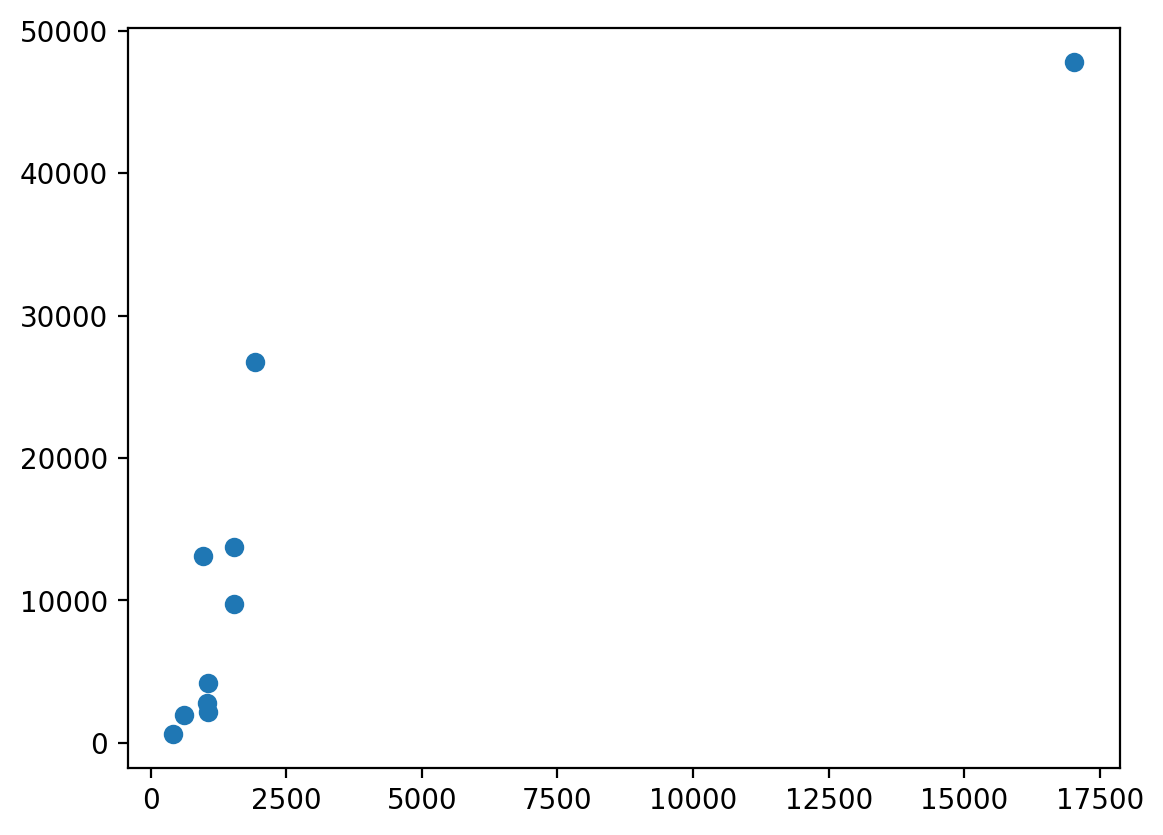

In [221]:
plt.scatter([np.mean(x[sublibrary == subl]) for subl in np.unique(sublibrary)],
                [np.var(x[sublibrary == subl])/np.mean(x[sublibrary == subl]) for subl in np.unique(sublibrary)])
for subl in np.unique(sublibrary):
    np.unique()

In [206]:
y_box = [x[sublibrary == subl] for subl in np.unique(sublibrary)]

In [215]:
box_data = pd.DataFrame({'log_counts' : x, 'sublibrary' : sublibrary})
box_data['log_counts'] = box_data['log_counts'].apply(lambda x : np.log10(x +1))

<Axes: xlabel='sublibrary', ylabel='log_counts'>

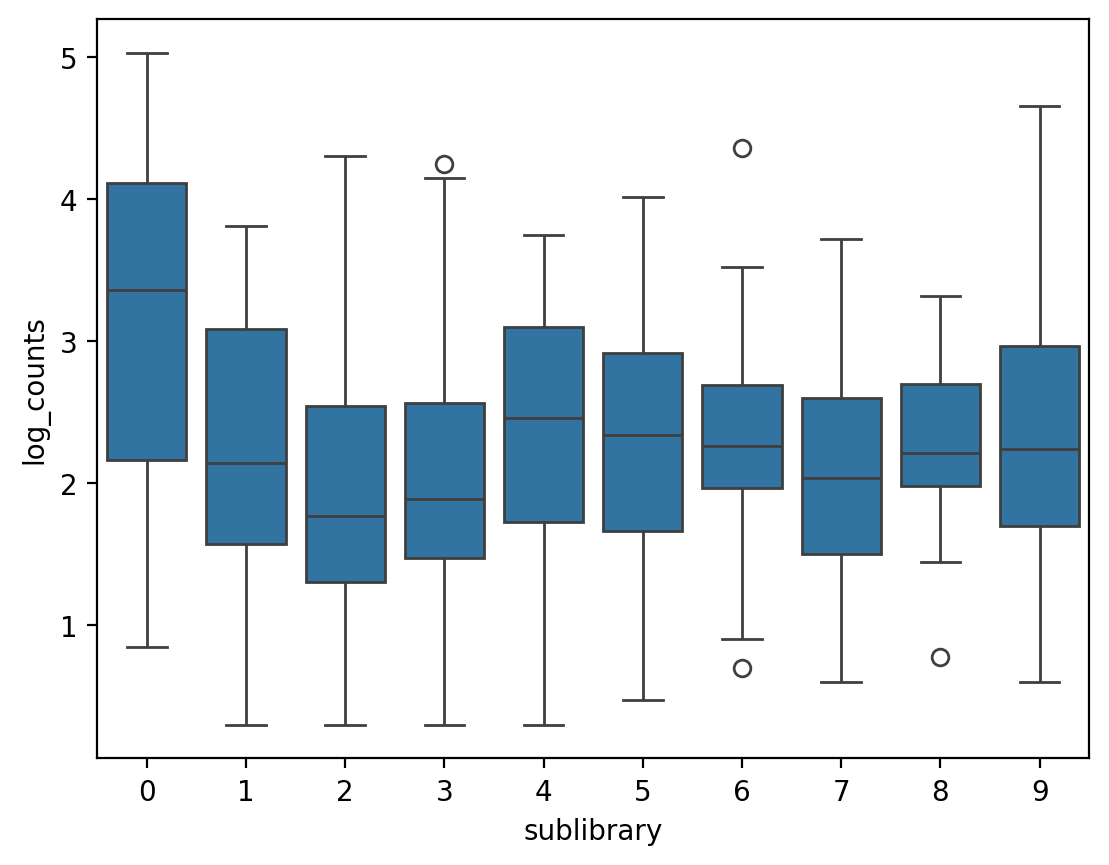

In [216]:
sns.boxplot(box_data, x='sublibrary', y='log_counts'
           )

In [209]:
?sns.boxplot

Signature:
sns.boxplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    dodge='auto',
    width=0.8,
    gap=0,
    whis=1.5,
    linecolor='auto',
    linewidth=None,
    fliersize=None,
    hue_norm=None,
    native_scale=False,
    log_scale=None,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Draw a box plot to show distributions with respect to categories.

A box plot (or box-and-whisker plot) shows the distribution of quantitative
data in a way that facilitates comparisons between variables or across
levels of a categorical variable. The box shows the quartiles of the
dataset while the whiskers extend to show the rest of the distribution,
except for points that are determined to be "outliers" using a method
that is a function of the inter-quartile range.

See the :ref:`tutorial <categorical_tutorial>` for more i

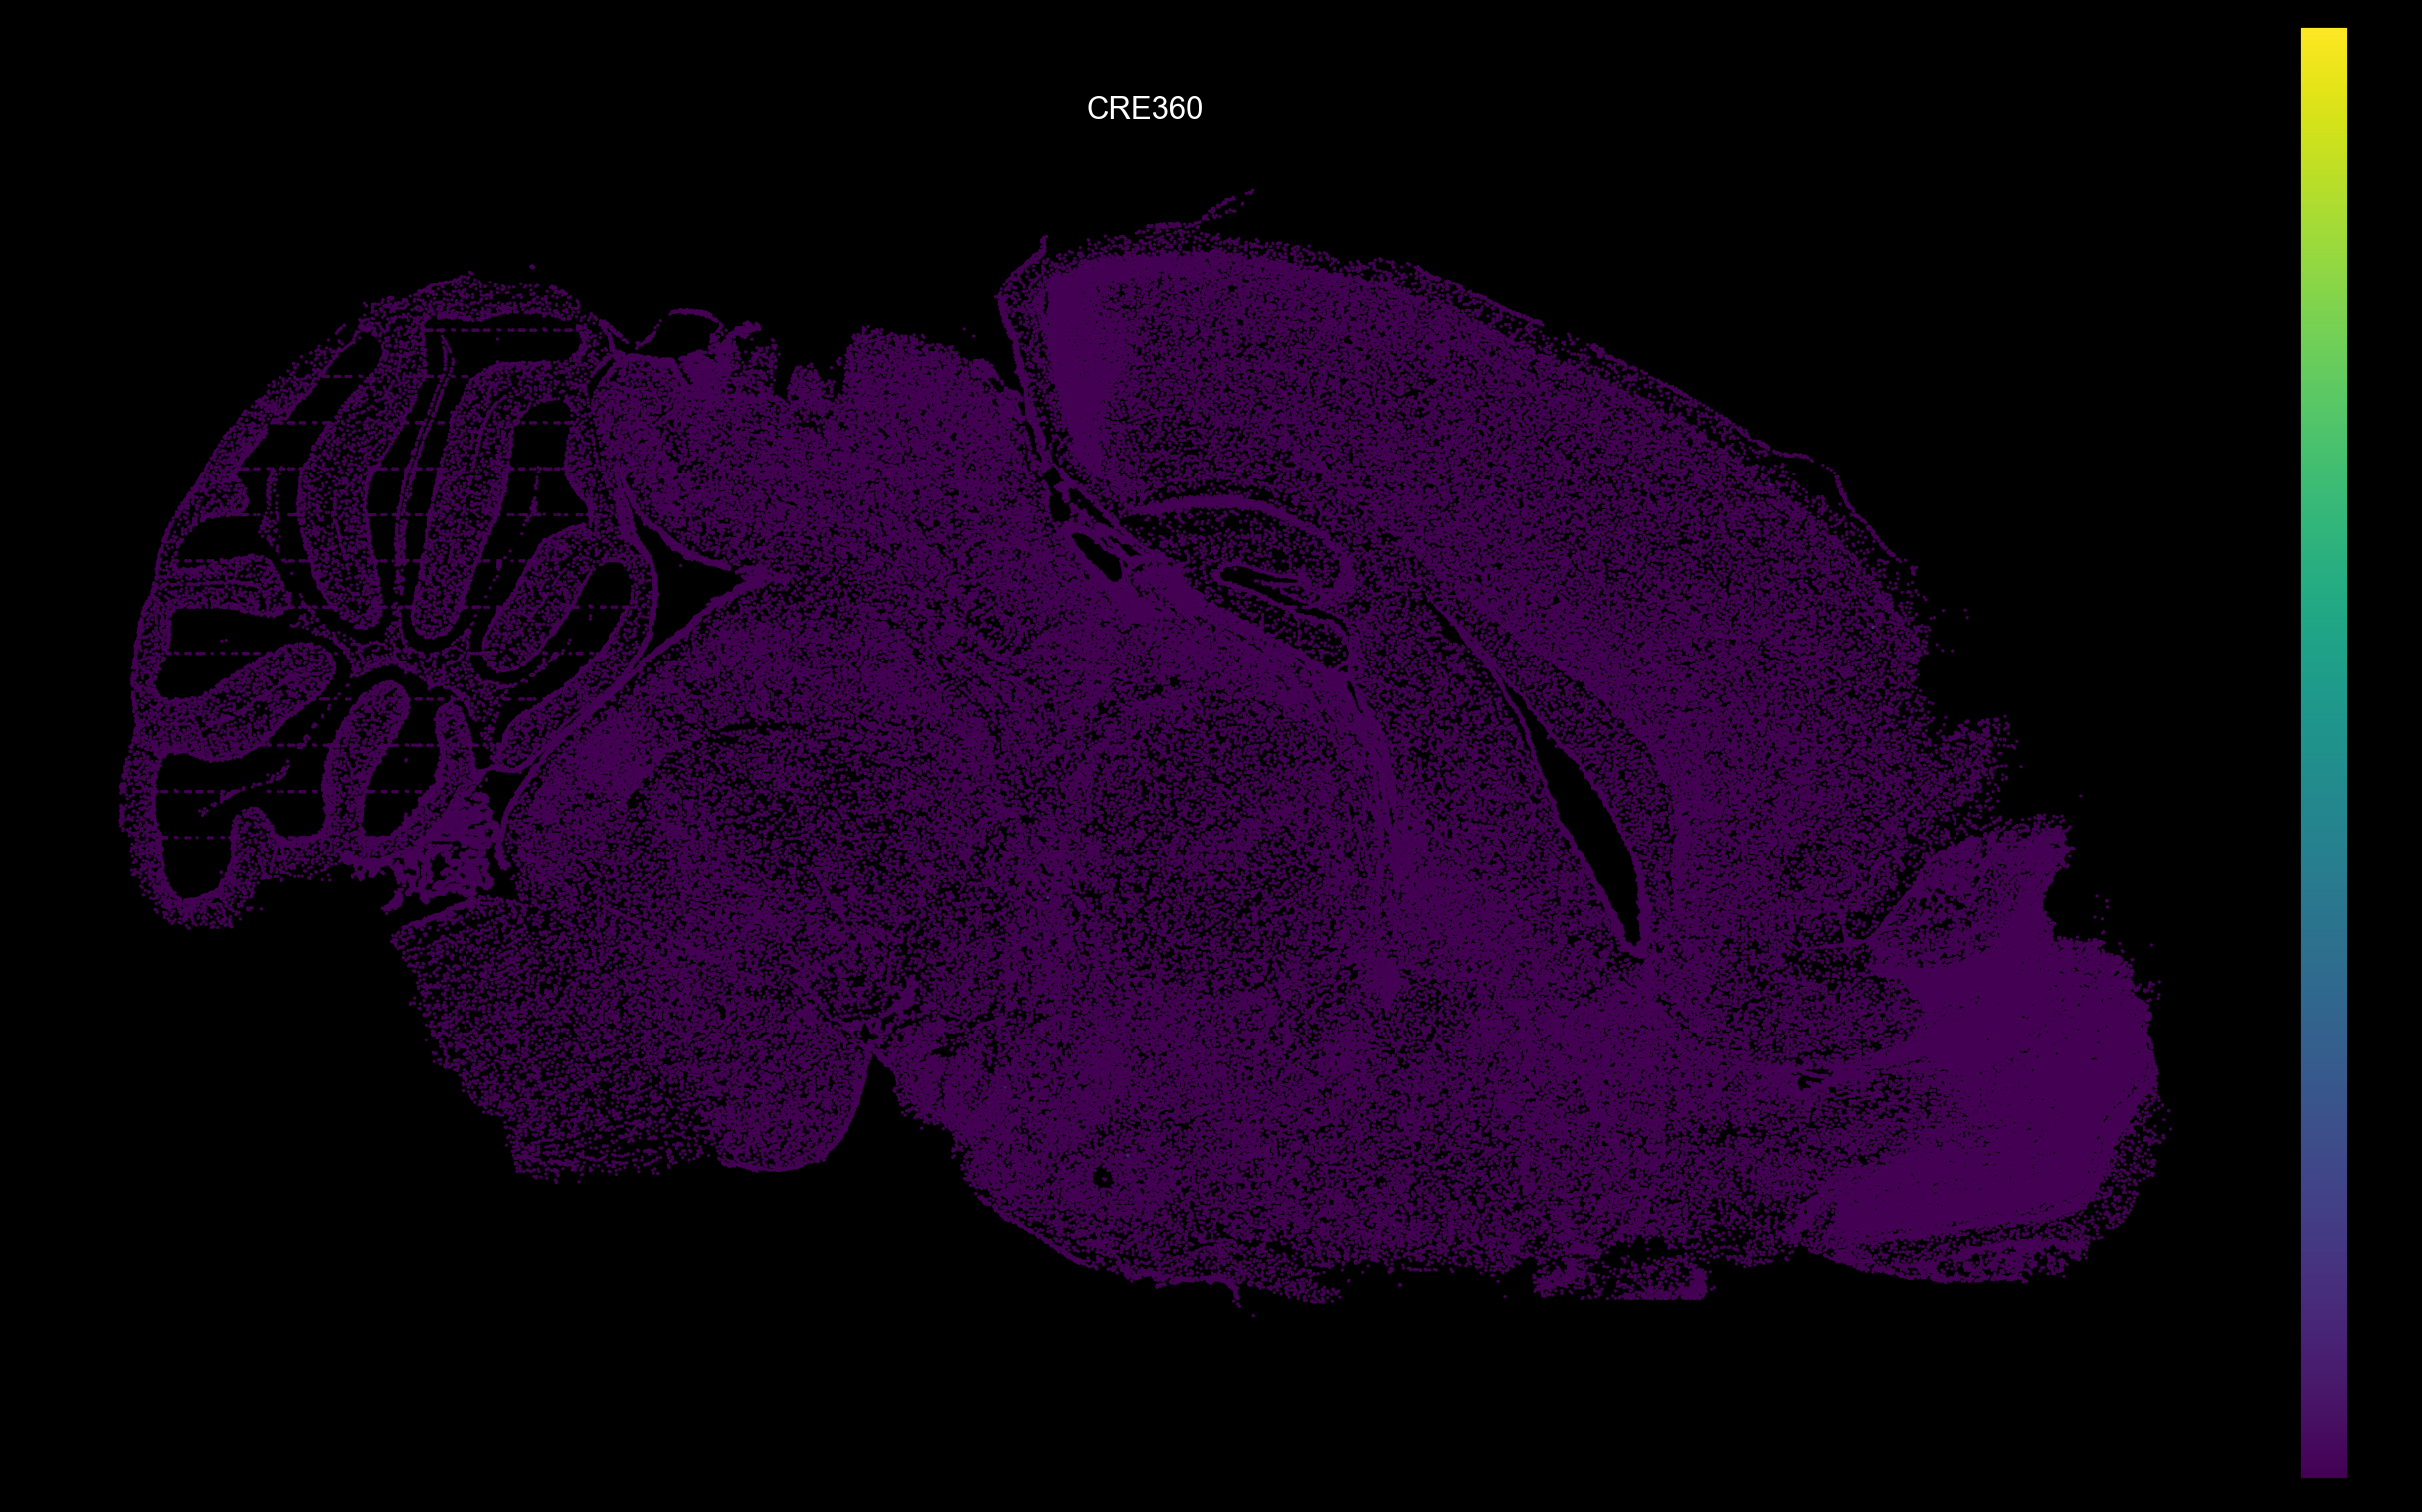

In [178]:
import pandas as pd

# Convert scdata.obsm['CRE'] to DataFrame for proper indexing
df_cre = pd.DataFrame(scdata.obsm['CRE'], index=scdata.obs_names)

# Define genes of interest
genes = df_cre.columns[:400]

# Normalize CRE spot counts to the nanopore sequencing counts before plotting
adata_temp = sc.AnnData(X=scdata.obsm['CRE'].iloc[:,:400]/(cts_seq+1), obs=scdata.obs.copy(), var=pd.DataFrame(index=genes), obsm=scdata.obsm.copy())
adata_temp.obsm['X_spatial'] = adata_temp.obsm['X_spatial'][:,::1]*[1,-1]

sc.set_figure_params(figsize=(20,12), facecolor='k', dpi_save=600, vector_friendly=True)

sc.pl.spatial(adata_temp, img_key=None, color=['CRE360'], spot_size=20,
              vmax=1, frameon=False, cmap='viridis')

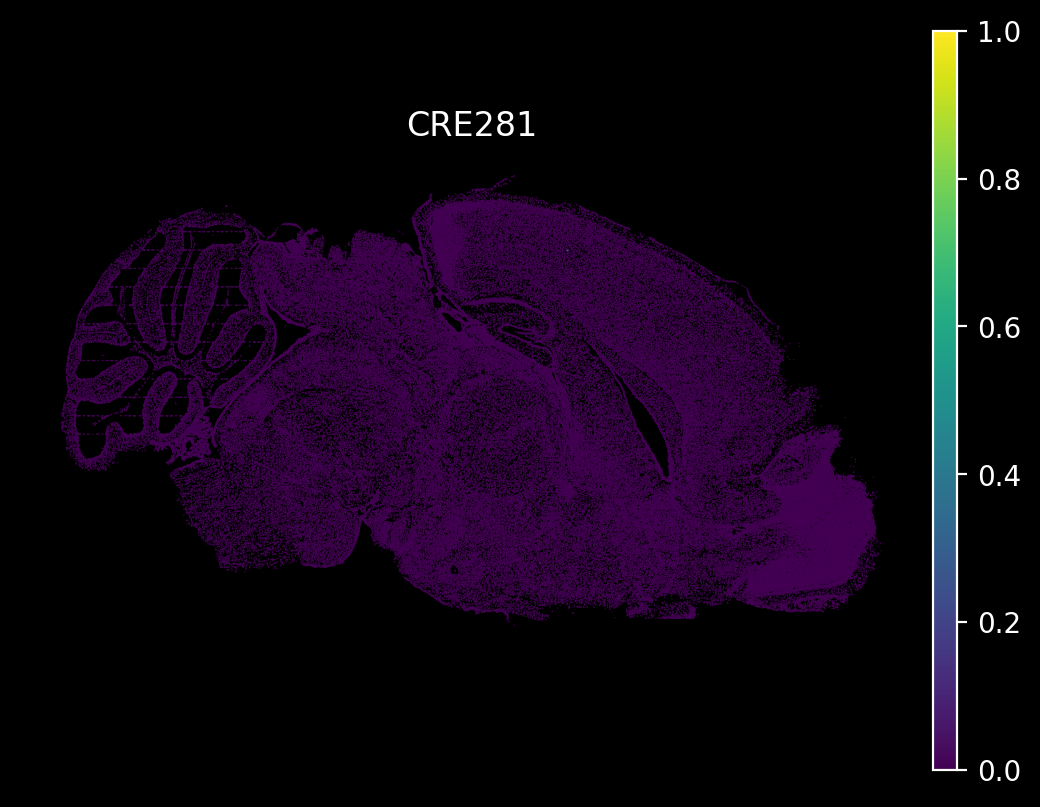

In [229]:
sc.pl.spatial(adata_temp, img_key=None, color=['CRE281'], spot_size=20,
              vmax=1, frameon=False, cmap='viridis')

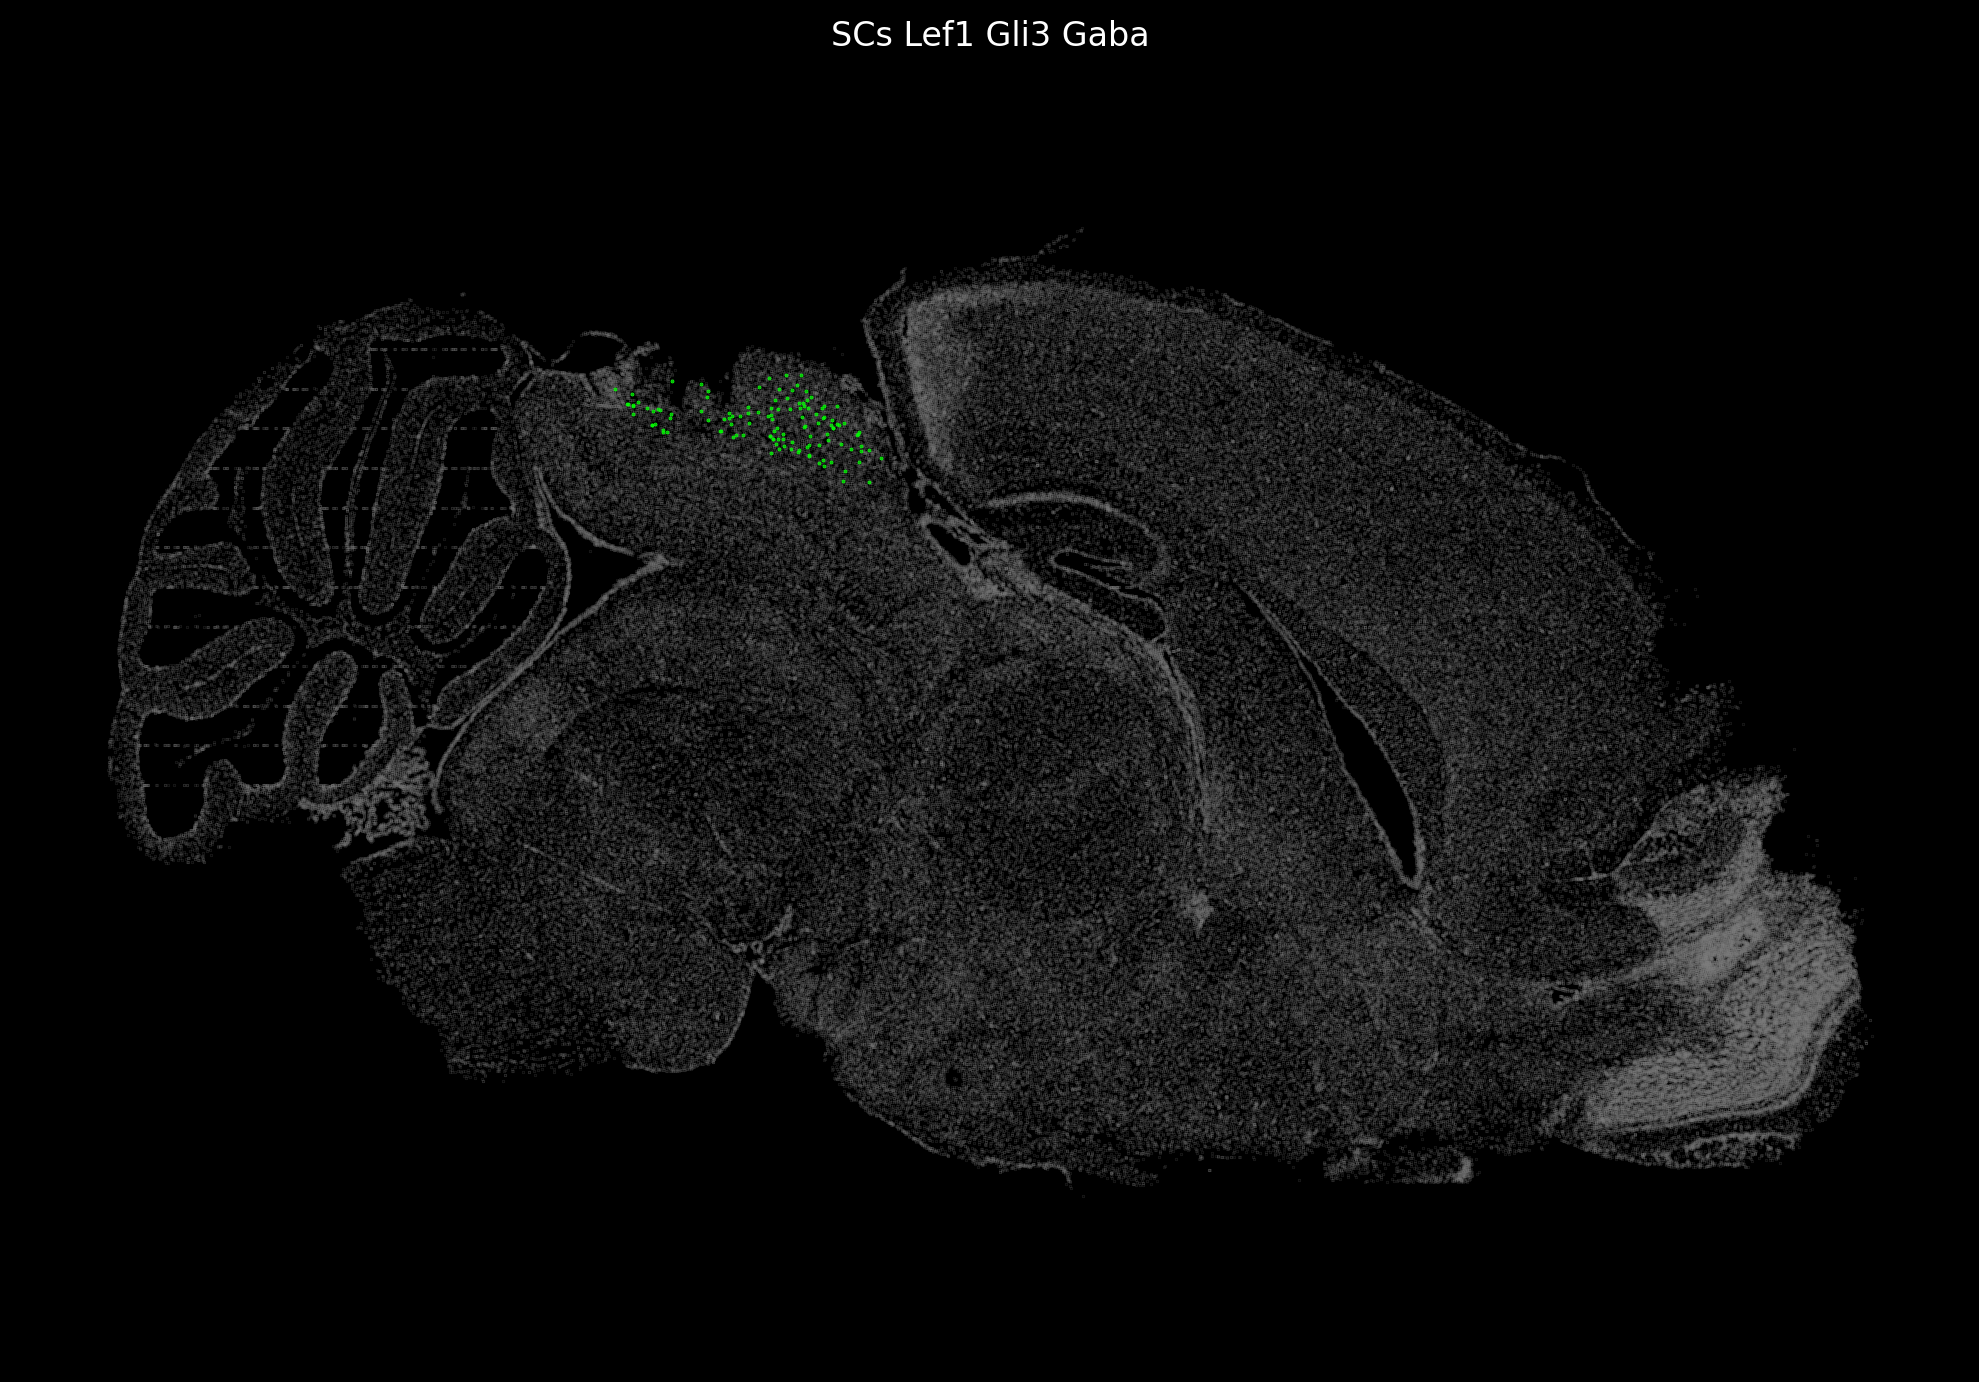

In [228]:
from spatial_funcs import *

plot_cell_subclass(scdata, subclass='SCs Lef1 Gli3 Gaba')

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_34972\605769115.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cre_df_ = cre_df.groupby(adata_temp.obs['subclass']).mean()
C:\Users\zgibbs\anaconda3\envs\scanpy\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\zgibbs\anaconda3\envs\scanpy\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


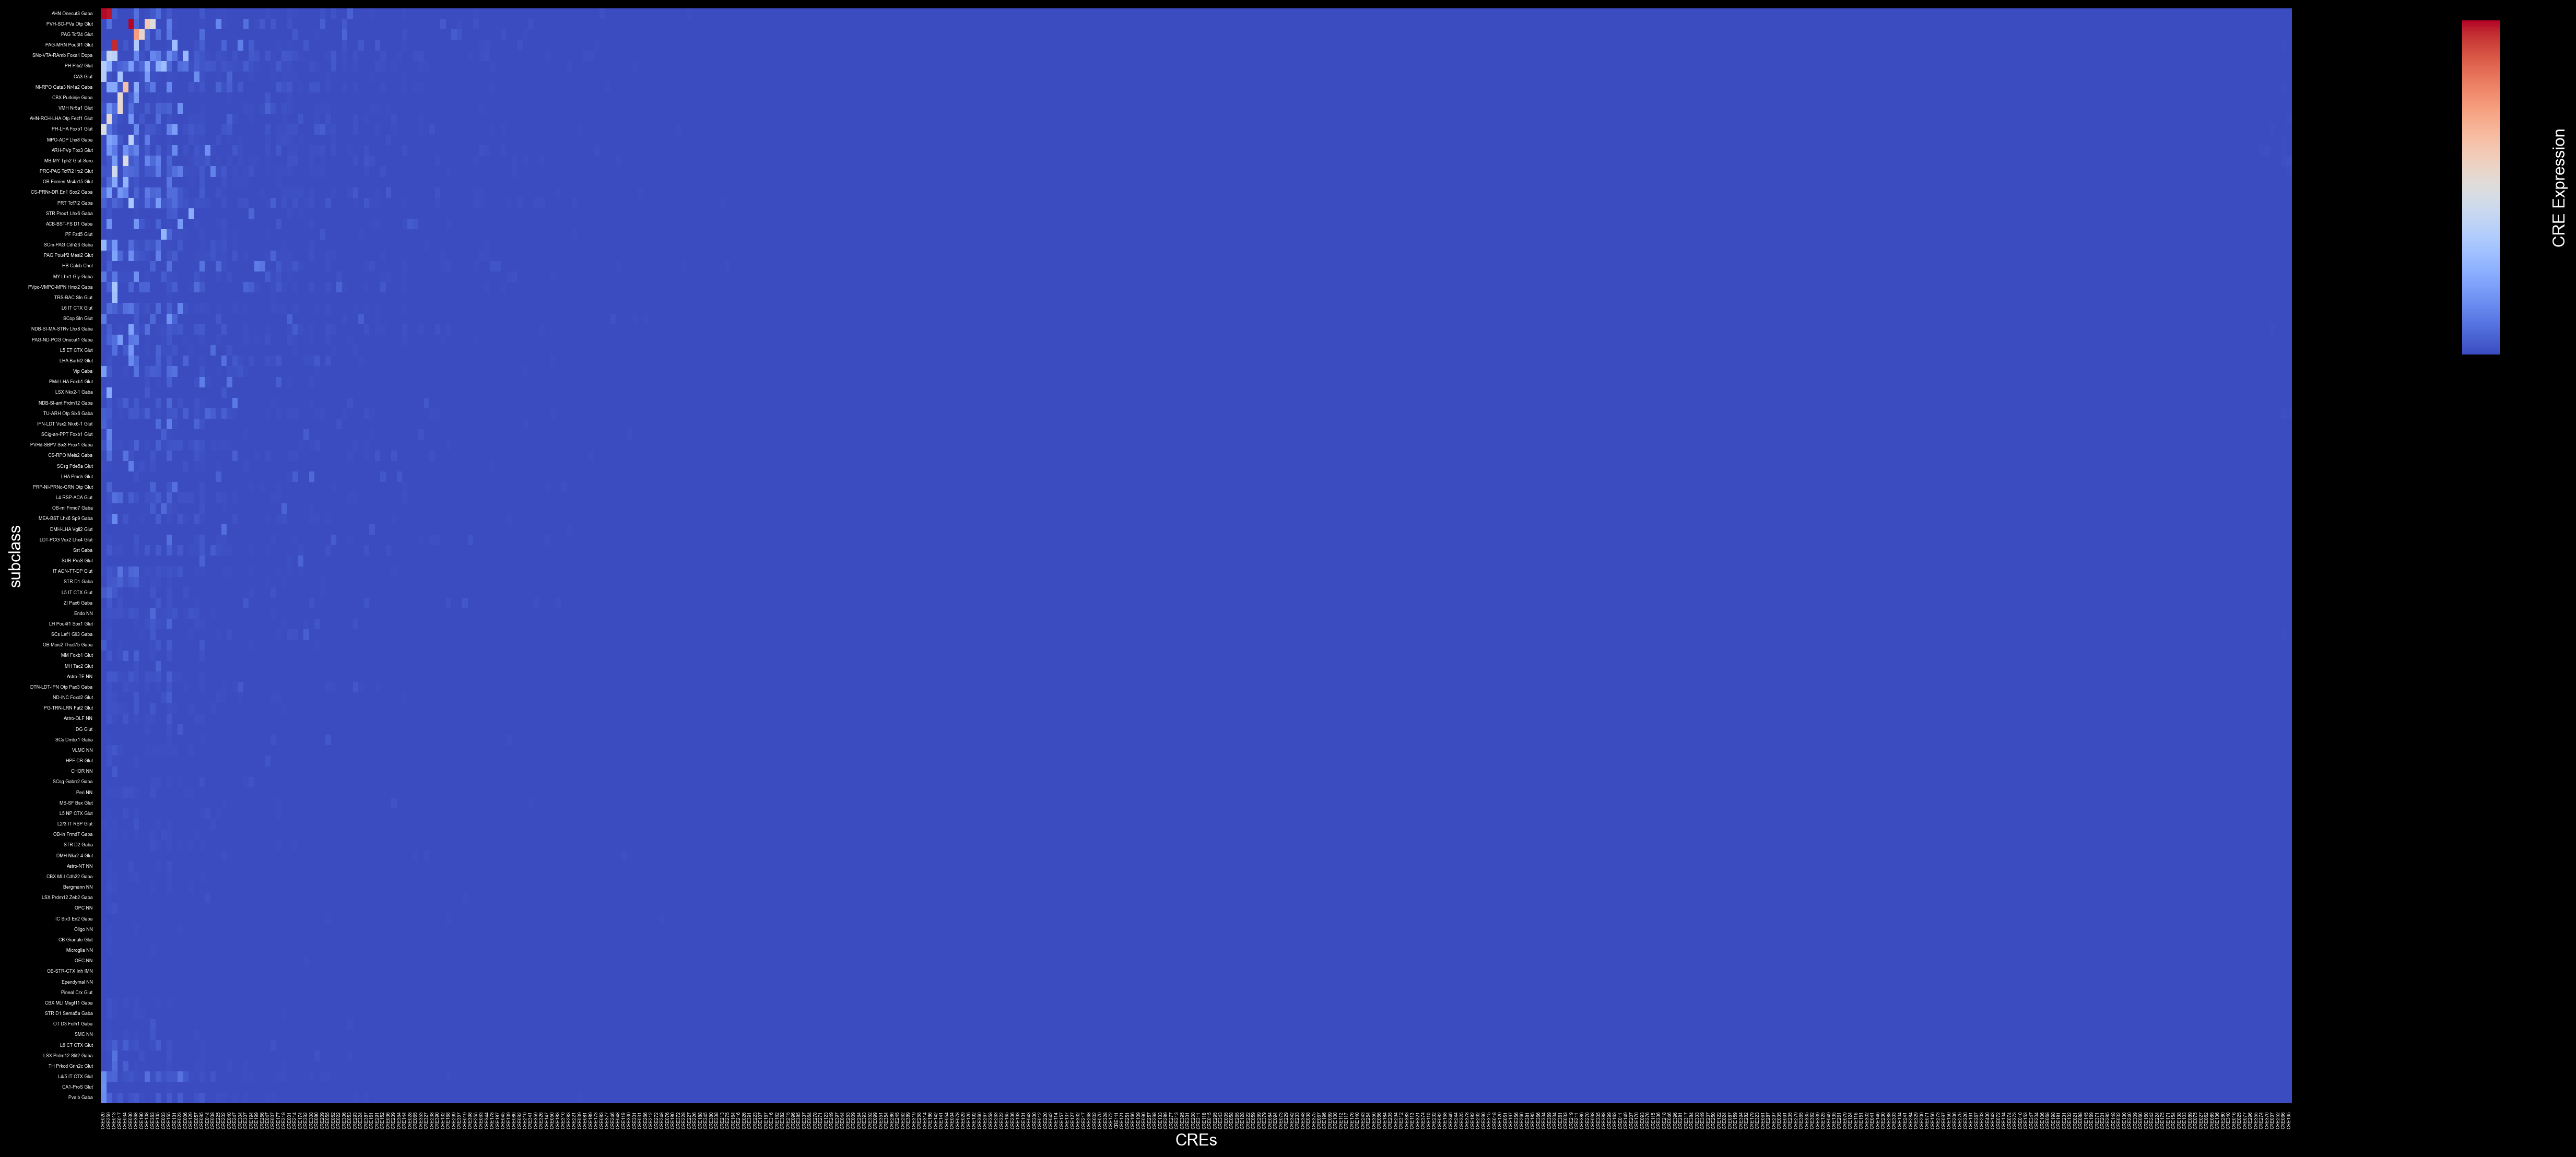

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc

# Assuming adata_temp is already defined
# adata_temp = sc.AnnData(X=scdata.obsm['CRE'], obs=scdata.obs.copy(), var=pd.DataFrame(index=genes))

# Ensure the data is in a suitable format for sns.clustermap
# Convert adata_temp.X (CRE expression) to a DataFrame
cre_df = pd.DataFrame(adata_temp.X, index=adata_temp.obs.index, columns=adata_temp.var.index)
cre_df_ = cre_df.groupby(adata_temp.obs['subclass']).mean()

# Now, we create the clustermap using seaborn's sns.clustermap
# We will use 'subclass' for row clustering and display it on the y-axis.

# The row cluster will be based on 'subclass', which we can group by
# sns.set(font_scale=1.2)  # Optional: Increase font size for readability

# Plot the clustermap
g = sns.clustermap(
    cre_df_,
    cmap="coolwarm",
    standard_scale=None,
    method="single",  # Clustering method
    metric="euclidean",  # Distance metric
    row_cluster=True,  
    col_cluster=True, 
    linewidths=0,
    figsize=(30, 20), 
    cbar_pos=(0.96, 0.5, 0.015, 0.2), 
    dendrogram_ratio=(0.01, 0.3),
    cbar_kws={'label': 'CRE Expression', 'drawedges':False},
    xticklabels=1, 
    yticklabels=1 
)

g.ax_row_dendrogram.set_visible(False) #suppress row dendrogram
g.ax_col_dendrogram.set_visible(False) #suppress column dendrogram
g.ax_heatmap.grid(False)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=4, color='w')  # Change x-axis tick label font size
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=4, color='w')  # Change y-axis tick label font size

g.ax_heatmap.yaxis.set_label_position("left")
g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.xaxis.set_label_text('CREs', size=14)
g.ax_heatmap.yaxis.set_label_text('subclass', size=14)

cbar = g.cax
# cbar.ticks(labelcolor='white')  # Change color of the color bar ticks
cbar.grid(False)  # Remove gridlines from the colorbar
# cbar.set_label('CRE Expression', fontsize=14, color='white')  # Change the color of the color bar label

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\241205_SFv8_mouse_brain\CRE_log1p_expression_by_subclass_clustering.png', dpi=500, bbox_inches='tight')
plt.show()

In [117]:
scdata.obsm['CRE'].iloc[:,:400]/(cts_seq+1)

,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE391,CRE392,CRE393,CRE394,CRE395,CRE396,CRE397,CRE398,CRE399,CRE400
Conv_zscan1_516--1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_516--2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_516--5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_516--6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_516--8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Conv_zscan1_086--761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_086--762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_086--763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan1_086--764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [147]:
seq_norm = (cts_seq+1)/np.sum(cts_seq+1)

In [149]:
np.sum(seq_norm)

np.float64(1.0)

In [173]:
np.where(scdata.uns['CRE_info']['labeling_type']=='region')

(array([  3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,
         16,  17,  18,  19, 156]),)

In [176]:
scdata.uns['CRE_info'][3:19]

,enh,label,labeling_type,subclass_num,best_subclass,sequence
3,chr18:77340500-77340999,Thalamus,region,151.0,TH_Prkcd_Grin2c_Glut,tttctgaacaccccactgatacctcaattccaccaccaagctcatt...
4,chr5:116732027-116732526,Thalamus,region,151.0,TH_Prkcd_Grin2c_Glut,TTCCTTTCAAGGACATCTTGGCAAATTCAAAAGTCGGCCACATCTC...
5,chr8:23523246-23523745,Thalamus,region,149.0,PVT-PT_Ntrk1_Glut,CTTTGATATCATCCCAAAGAAGTCTCCCTCCGACTATCTGCAAGGA...
6,chr15:92512225-92512724,Thalamus,region,149.0,PVT-PT_Ntrk1_Glut,GTGTTATCTAAGTGATGCCTTTTGAAGATTAATGTCAGCATCACAG...
7,chr15:84277539-84278038,Thalamus,region,93.0,RT-ZI_Gnb3_Gaba,AACTTCCCTCTGGTGTCTTAGTGGCCTTTTCTGTCGCCCACTACTT...
8,chr7:38318050-38318549,Dentate Gyrus,region,37.0,DG_Glut,TCCACATGATGTCTGAAATGAGATTTACTCCTCTTCTGTCAGCTGT...
9,chr8:47566720-47567219,Lateral Septal Complex,region,71.0,LSX_Prdm12_Zeb2_Gaba,AACATCAACTTACACAACCGTCACTCAAATCTCTTTGTCCTCCCAG...
10,chr6:131301569-131302068,Lateral Septal Complex,region,70.0,LSX_Prdm12_Slit2_Gaba,TTTAAATATGAAAGGAGAATAACACCAATCTCCTGTGACCTGAAAA...
11,chr1:57983476-57983975,Lateral Septal Complex,region,71.0,LSX_Prdm12_Zeb2_Gaba,tatattttcactaaaaggggaaaTTtaaaaagggaaacaatagtgg...
12,chr15:87158794-87159293,Lateral Septal Complex,region,72.0,LSX_Sall3_Lmo1_Gaba,TTTCTTACCTTTCTTTCTGTGTATTGTGTTAGCTTCATTTATAGCC...
